# **🏷️ Classification Pipeline 01**

**Dataset:**

- Breast Cancer Wisconsin dataset from sklearn, containing numerical features for binary classification.

**Pipeline Components:**

- `ColumnTransformer` for preprocessing:

  - `StandardScaler` applied to numerical features.

  - `OneHotEncoder` applied to categorical features

- `Pipeline` from sklearn.pipeline used to chain preprocessing and modeling steps.

**Model:**

- `LogisticRegression` (can be swapped with other classifiers).

**Hyperparameter Tuning:**

- `GridSearchCV` used for cross-validated hyperparameter optimization (e.g., tuning alpha in Ridge).

**Evaluation Metrics:**

- `Accuracy, Precision, Recall, F1-score, ROC AUC, Log Loss`.

**Visualization (Optional):**

- `Confusion Matrix, ROC Curve, Precision-Recall Curve`.

---
# **⬜ Import dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    log_loss, roc_curve, precision_recall_curve, confusion_matrix
)

---
# **⬜ Load from sk-learn**

In [2]:
# Load dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

In [3]:
# Simulate some categorical features
X['mean radius category'] = pd.cut(X['mean radius'], bins=3, labels=['small', 'medium', 'large'])

---
# **🟨 Train-test split**

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Identify feature types
num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = X.select_dtypes(include='category', exclude='number').columns.tolist() + \
               X.select_dtypes(include='object').columns.tolist()

---
# **🟨 Column Transformer**

In [6]:
# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

---
# **🟨 Define Models**

In [7]:
# Define models and param grids for GridSearchCV (can be empty dict if no tuning)
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=500),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [None, 10, 20]
        }
    },
    'SVM': {
        'model': SVC(probability=True),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['linear', 'rbf']
        }
    }
}

---
# **🟨 Training Pipeline**

Training LogisticRegression...


C:\Users\joeln\AppData\Local\Temp\ipykernel_372\1860823428.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(recall, precision)


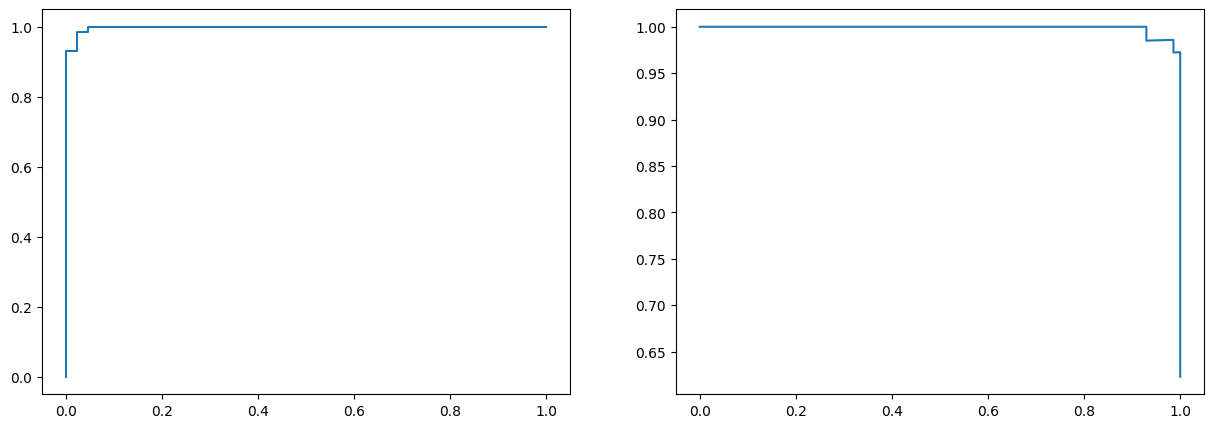

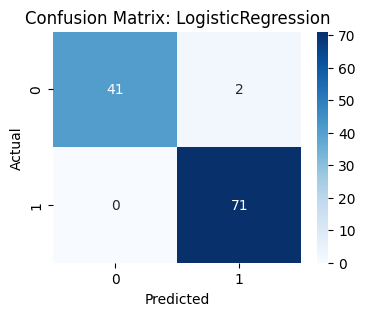

Training RandomForest...


C:\Users\joeln\AppData\Local\Temp\ipykernel_372\1860823428.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(recall, precision)


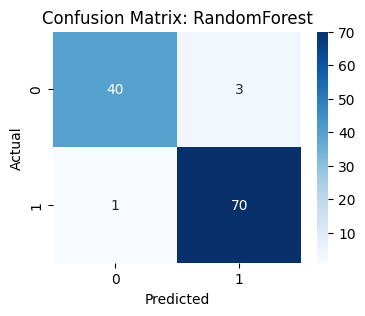

Training SVM...


C:\Users\joeln\AppData\Local\Temp\ipykernel_372\1860823428.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pr_auc = np.trapz(recall, precision)


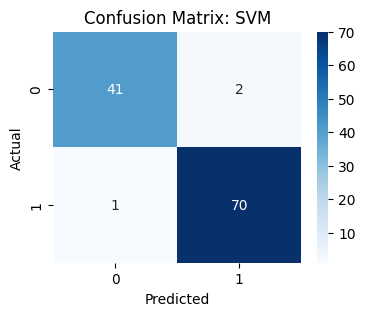

<Figure size 640x480 with 0 Axes>

In [10]:
# Train, tune, and evaluate all models
results = []
plt.figure(figsize=(15, 5))

# Create subplots for ROC and PR curves side-by-side
plt_roc = plt.subplot(1, 2, 1)
plt_pr = plt.subplot(1, 2, 2)

for name, mp in models.items():
    print(f"Training {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', mp['model'])
    ])

    param_grid = mp['params']

    if param_grid:
        gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
        gs.fit(X_train, y_train)
        best_model = gs.best_estimator_
        best_params = gs.best_params_
    else:
        pipeline.fit(X_train, y_train)
        best_model = pipeline
        best_params = {}

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # Metrics
    metrics = {
        'Model': name,
        'Best Params': best_params,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'Log Loss': log_loss(y_test, y_proba)
    }
    results.append(metrics)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt_roc.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC AUC']:.2f})")

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = np.trapz(recall, precision)
    plt_pr.plot(recall, precision, label=f"{name}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Format ROC plot
plt_roc.plot([0, 1], [0, 1], 'k--', lw=1)
plt_roc.set_xlabel('False Positive Rate')
plt_roc.set_ylabel('True Positive Rate')
plt_roc.set_title('ROC Curve')
plt_roc.legend()

# Format PR plot
plt_pr.set_xlabel('Recall')
plt_pr.set_ylabel('Precision')
plt_pr.set_title('Precision-Recall Curve')
plt_pr.legend()

plt.tight_layout()
plt.show();

In [9]:
# Display results in a table
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                Model                                        Best Params  \
0  LogisticRegression                             {'classifier__C': 0.1}   
1        RandomForest  {'classifier__max_depth': None, 'classifier__n...   
2                 SVM  {'classifier__C': 1, 'classifier__kernel': 'rbf'}   

   Accuracy  Precision    Recall  F1 Score   ROC AUC  Log Loss  
0  0.982456   0.972603  1.000000  0.986111  0.998035  0.081307  
1  0.964912   0.958904  0.985915  0.972222  0.998362  0.082766  
2  0.973684   0.972222  0.985915  0.979021  0.997380  0.076472  


| Metric     | Description                                                                                 | When to Use                                               |
|------------|---------------------------------------------------------------------------------------------|-----------------------------------------------------------|
| `Accuracy`   | Overall ratio of correct predictions                                                        | When classes are balanced                                 |
| `Precision`  | Proportion of positive predictions that are correct                                        | When false positives are costly                           |
| `Recall`     | Proportion of actual positives that are correctly identified                               | When false negatives are costly                           |
| `F1 Score`   | Harmonic mean of precision and recall                                                     | When balance between precision and recall is needed     |
| `ROC AUC`    | Area under ROC curve measuring separability                                               | When you want to evaluate model's ranking ability         |
| `Log Loss`   | Penalizes false confident predictions, measures probabilistic predictions quality          | When well-calibrated probabilities are important         |


---
---
---